## Raport 2
Adam Freń, Karol Garbaczewski

In [1]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

### 1.
Z populacji generalnej o rozkładzie normalnym $N (\mu, \sigma = 0.2)$ pobrano próbę (dane dołączone do
listy). Dla $\alpha$ = 0.05 zweryfikuj hipotezy
+ $\mu \ne 1.5$
+  $\mu < 1.5$
+  $\mu > 1.5$ 

Narysuj odpowiednie obszary kytyczne i wyznacz p-wartości dla każdej z powyższych hipotez. Odpo-
wiedz na pytanie co stanie się kiedy zwiększymy bądź zmniejszymy poziom ufności.
Przyjmujemy że hipoteza zerowa tutaj jest równa $H_0: \mu = 1.5$

In [2]:
plik=open("./lista7zad1.txt",'r')
p=plik.read()
p=p.split(",")
N=1_000_000
for i in range(len(p)):
    p[i] = float(p[i])

sigma=0.2
x_dash=np.mean(p)   
Z=x_dash
alpha=0.05
left_crit=(-1)*scipy.stats.norm.ppf(q=1-alpha,loc=0,scale=1)
right_crit=scipy.stats.norm.ppf(q=1-alpha,loc=0,scale=1)
both_crit=scipy.stats.norm.ppf(q=1-(alpha/2),loc=0,scale=1)
mu=1.5
Z=(Z-mu)/(sigma/np.sqrt(len(p)))
t=np.linspace(-3,3,500)

## Dla hipotezy alternatywnej $\mu \ne 1.5$ (test obustronny)

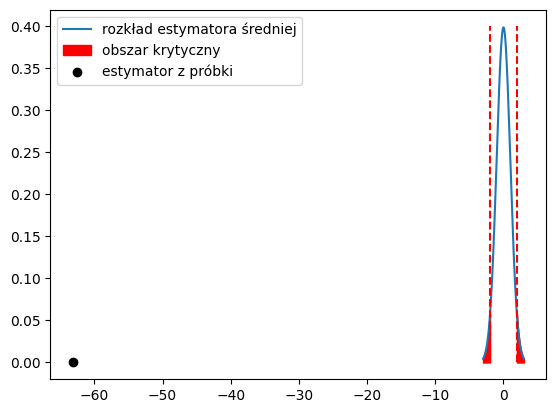

Wartość p: 0.0


In [3]:
pdf_draw=[scipy.stats.norm.pdf(x) for x in t]
plt.plot(t,pdf_draw,label="rozkład estymatora średniej")
plt.fill_between(x=t,y1=pdf_draw,where = (t<-both_crit),color='r',label="obszar krytyczny")
plt.fill_between(x=t,y1=pdf_draw,where = (t>both_crit),color='r')
plt.vlines([-both_crit, both_crit], ymin=0, ymax=0.4, linestyles="--", color="red")
plt.scatter(Z, 0, color="black", label="estymator z próbki")
plt.legend()
plt.show()
p_value=2*scipy.stats.norm.sf(abs(Z))
print("Wartość p:",p_value)

Statystyka Z wpada w obszar krytyczny,więc odrzucamy hipotezę zerową i nie ma podstaw do odrzucenia hipotezę alternatywną.

### Sprawdzenie prawdopodopodobieństwa błędu I i II rodzaju

In [4]:
M=100_000
mu=1.5
sigma=0.2
alpha=0.05
N=1000
acc = 0
counter=0
for i in range(M):
    T=np.random.normal(mu,sigma,N)
    Z_emp=np.mean(T)-mu
    Z_emp=Z_emp/((sigma)/(np.sqrt(N)))
    if -both_crit>Z_emp or Z_emp>both_crit:
        acc+=1  
print(f"bład 1. rodzaju wynosi: {acc/M}")



alternatives=[1.45,1.48,1.52,1.55]
for mean in alternatives:
    acc = 0
    counter=0
    for i in range(M):
        T=np.random.normal(mean,sigma,N)
        Z_emp=np.mean(T)-mu
        Z_emp=Z_emp/((sigma)/(np.sqrt(N)))
        if -both_crit<Z_emp and Z_emp<both_crit:
            acc+=1  
    print(f"bład 2. rodzaju dla średniej {mean} wynosi: {acc/M}, moc testu: {1-acc/M}")


bład 1. rodzaju wynosi: 0.04929
bład 2. rodzaju dla średniej 1.45 wynosi: 0.0, moc testu: 1.0
bład 2. rodzaju dla średniej 1.48 wynosi: 0.11308, moc testu: 0.88692
bład 2. rodzaju dla średniej 1.52 wynosi: 0.11498, moc testu: 0.88502
bład 2. rodzaju dla średniej 1.55 wynosi: 0.0, moc testu: 1.0


## Dla hipotezy alternatywnej $\mu < 1.5$ (test lewostronny)

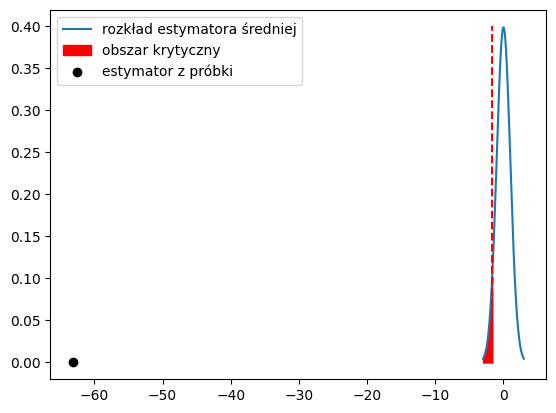

Wartość p: 0.0


In [5]:
plt.plot(t,pdf_draw,label="rozkład estymatora średniej")
plt.fill_between(x=t,y1=pdf_draw,where = (t<left_crit),color='r',label="obszar krytyczny")
plt.vlines([left_crit], ymin=0, ymax=0.4, linestyles="--", color="red")
plt.scatter(Z, 0, color="black", label="estymator z próbki")
plt.legend()
plt.show()
p_value=scipy.stats.norm.cdf(Z)
print("Wartość p:",p_value)

Statystyka Z wpada w obszar krytyczny,więc odrzucamy hipotezę zerową i możemy przyjąć hipotezę alternatywną.

### Sprawdzenie prawdopodopodobieństwa błędu I i II rodzaju

In [6]:
acc = 0
counter=0
for i in range(M):
    T=np.random.normal(mu,sigma,N)
    Z_emp=np.mean(T)-mu
    Z_emp=Z_emp/((sigma)/(np.sqrt(N)))
    if left_crit>Z_emp:
        acc+=1  
print(f"bład 1. rodzaju wynosi: {acc/M}")



alternatives=[1.45,1.47,1.48,1.49]
for mean in alternatives:
    acc = 0
    counter=0
    for i in range(M):
        T=np.random.normal(mean,sigma,N)
        Z_emp=np.mean(T)-mu
        Z_emp=Z_emp/((sigma)/(np.sqrt(N)))
        if left_crit<Z_emp:
            acc+=1  
    print(f"bład 2. rodzaju dla średniej {mean} wynosi: {acc/M}, moc testu: {1-acc/M}")

bład 1. rodzaju wynosi: 0.04916
bład 2. rodzaju dla średniej 1.45 wynosi: 0.0, moc testu: 1.0
bład 2. rodzaju dla średniej 1.47 wynosi: 0.00105, moc testu: 0.99895
bład 2. rodzaju dla średniej 1.48 wynosi: 0.06397, moc testu: 0.93603
bład 2. rodzaju dla średniej 1.49 wynosi: 0.52349, moc testu: 0.47651


## Dla hipotezy alternatywnej $\mu > 1.5$ (test prawostronny)

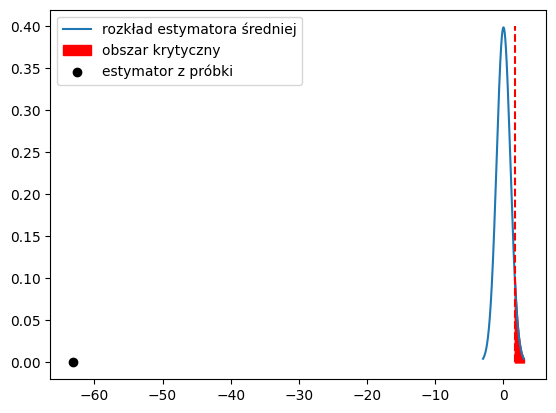

Wartość p: 1.0


In [7]:
plt.plot(t,pdf_draw,label="rozkład estymatora średniej")
plt.fill_between(x=t,y1=pdf_draw,where = (t>right_crit),color='r',label="obszar krytyczny")
plt.vlines([right_crit], ymin=0, ymax=0.4, linestyles="--", color="red")
plt.scatter(Z, 0, color="black", label="estymator z próbki")
plt.legend()
plt.show()
p_value=scipy.stats.norm.sf(Z)
print("Wartość p:",p_value)

### Sprawdzenie prawdopodopodobieństwa błędu I i II rodzaju

In [8]:
acc = 0
counter=0
for i in range(M):
    T=np.random.normal(mu,sigma,N)
    Z_emp=np.mean(T)-mu
    Z_emp=Z_emp/((sigma)/(np.sqrt(N)))
    if Z_emp>right_crit:
        acc+=1  
print(f"bład 1. rodzaju wynosi: {acc/M}")



alternatives=[1.51,1.52,1.53,1.55]
for mean in alternatives:
    acc = 0
    counter=0
    for i in range(M):
        T=np.random.normal(mean,sigma,N)
        Z_emp=np.mean(T)-mu
        Z_emp=Z_emp/((sigma)/(np.sqrt(N)))
        if Z_emp<right_crit:
            acc+=1  
    print(f"bład 2. rodzaju dla średniej {mean} wynosi: {acc/M}, moc testu: {1-acc/M}")

bład 1. rodzaju wynosi: 0.05002
bład 2. rodzaju dla średniej 1.51 wynosi: 0.52553, moc testu: 0.47446999999999995
bład 2. rodzaju dla średniej 1.52 wynosi: 0.06397, moc testu: 0.93603
bład 2. rodzaju dla średniej 1.53 wynosi: 0.00102, moc testu: 0.99898
bład 2. rodzaju dla średniej 1.55 wynosi: 0.0, moc testu: 1.0


Statystyka Z wpada w obszar krytyczny,więc odrzucamy hipotezę alternatywną i możemy przyjąć hipotezę zerową.

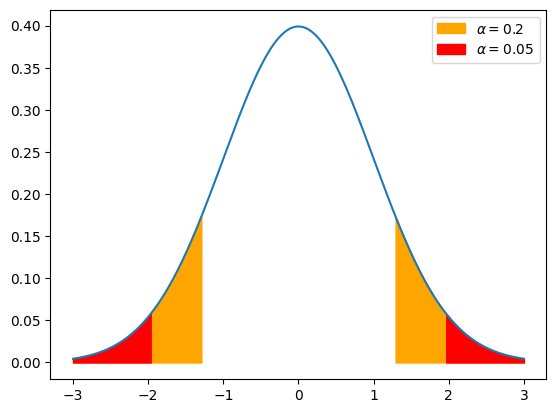

In [9]:
plt.plot(t,pdf_draw)
alpha=0.2
both_crit=scipy.stats.norm.ppf(q=1-(alpha/2),loc=0,scale=1)
plt.fill_between(x=t,y1=pdf_draw,where = (t<-both_crit),color='orange',label=r"$\alpha = 0.2$")
plt.fill_between(x=t,y1=pdf_draw,where = (t>both_crit),color='orange')
alpha=0.05
both_crit=scipy.stats.norm.ppf(q=1-(alpha/2),loc=0,scale=1)
plt.fill_between(x=t,y1=pdf_draw,where = (t<-both_crit),color='r',label=r"$\alpha = 0.05$")
plt.fill_between(x=t,y1=pdf_draw,where = (t>both_crit),color='r')
plt.legend()
plt.show()

Z wykresu widać że wraz ze wzrostem $\alpha$ obszar krytyczny się zwiększa.Dokładnie takie samo zachowanie obserwujemy w testach jednostronnych

## 2.

W zadaniu drugim odrazu policzmy pod każdą hipotezą prawdopodobieństwa błęów I i II rodzaju. Podobnie jak w zadaniu 1. jeśli zwiększymy $\alpha$ zwiększymy obszar krytyczny dla którego odrzucamy hipotezę zerową. Wykres powyżej bardzo dobrze oddaje intuicję.

In [10]:
plik =open("lista7zad2.txt", "r")
p = plik.read()
p = p.split(",")
dane = np.zeros(len(p))
for i in range(len(p)):
    dane[i] = float(p[i])

print(len(dane))

1000


# $H_{1}:\quad \sigma \neq 1.5$ 

In [11]:
# H0 = wariancja = 1,5
# H1 wariancja != 1,5

# statystyka chisquare dla naszej próbki 
h0_var = 1.5
srednia_populacji = 0.2
n = len(dane)
alfa = 0.05

# Estymator s2

# znamy naszą średnią populacji więc mamy n -stopni swobody
chi_probka = np.sum((dane - srednia_populacji)**2) / h0_var
chi_left = scipy.stats.chi2.ppf(alfa/2,df=n)
chi_right = scipy.stats.chi2.ppf(1-alfa/2, df=n)
p_value = 2 * min(scipy.stats.chi2.cdf(chi_probka, df=n),scipy.stats.chi2.sf(chi_probka, df=n) )
print(p_value)
# wiemy że nasz estymator ma rozkład chi-2 z n-1 stopniami swobody
# liczymy kwantyle dla poz. istotnosci 1-alfa


8.076063894477226e-137


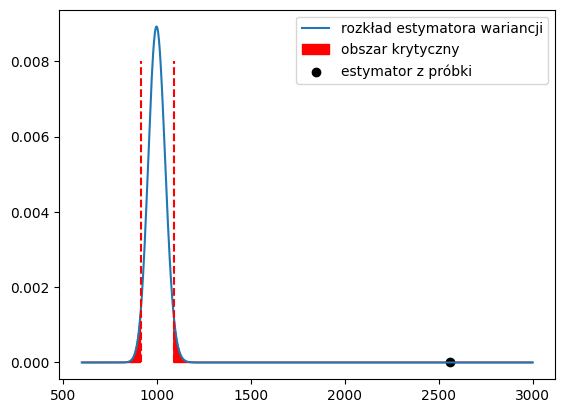

In [12]:
argumenty = np.linspace(600,3000, 1000)

plt.plot(argumenty, scipy.stats.chi2.pdf(argumenty, df=n), label="rozkład estymatora wariancji")
plt.vlines([chi_left, chi_right], ymin=0, ymax=0.008, linestyles="--", color="red")
plt.fill_between(x=argumenty,y1=scipy.stats.chi2.pdf(argumenty, df=n),where = (argumenty < chi_left) | (argumenty > chi_right),color='r', label="obszar krytyczny")
plt.scatter(chi_probka, 0, color="black", label="estymator z próbki")
plt.legend()


### Prawdopodobieństwo popełnienia błędów 1-2 rodzaju

In [13]:
# 1 rodzaj odrzucamy hipotezę zerową gdy jest prawdziwa
# 2 rodzaj przyjmujemy hipotezę zerową gdy jest fałszywa

# 1 
trials = 1000
rejected = 0
for i in range(trials):
    sample = np.random.normal(loc=0.2, scale=np.sqrt(1.5), size=1000)
    chi_sample = np.sum((sample - srednia_populacji)**2)/h0_var
    if chi_left > chi_sample or chi_sample > chi_right:
        rejected += 1
print(f"błąd 1-szego rodzaju {rejected/trials}")

# 2 
# sprawdzimy błąd 2. rodzaju dla kilku wartości 
alternatives = [0.1, 1.3, 1.6]

for var in alternatives:
    accepted = 0
    for i in range(trials):
        sample = np.random.normal(loc=0.2, scale=np.sqrt(var), size=1000)
        chi_sample = np.sum((sample - srednia_populacji)**2)/h0_var
        if chi_left < chi_sample < chi_right:
            accepted += 1
    print(f"bład 2. rodzaju dla wariancji {var} wynosi: {accepted/trials}, moc testu: {1-accepted/trials}")


błąd 1-szego rodzaju 0.057
bład 2. rodzaju dla wariancji 0.1 wynosi: 0.0, moc testu: 1.0
bład 2. rodzaju dla wariancji 1.3 wynosi: 0.113, moc testu: 0.887
bład 2. rodzaju dla wariancji 1.6 wynosi: 0.67, moc testu: 0.32999999999999996


Odrzucamy hipotezę zerową na rzecz hipotezy alternatywnej n poziomie istotności 0.05. 

# $ H_{1}: \quad  \alpha > 1.5 $

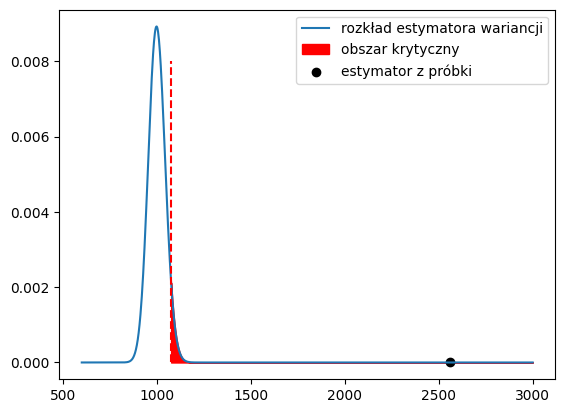

In [14]:
chi_right = scipy.stats.chi2.ppf(1-alfa, df=n)
p_value = scipy.stats.chi2.sf(chi_probka, df=n)

plt.plot(argumenty, scipy.stats.chi2.pdf(argumenty, df=n), label="rozkład estymatora wariancji")
plt.vlines( chi_right, ymin=0, ymax=0.008, linestyle="--", color="red")
plt.fill_between(x=argumenty,y1=scipy.stats.chi2.pdf(argumenty, df=n),where =(argumenty > chi_right), color='r', label="obszar krytyczny")
plt.scatter(chi_probka, 0, color="black", label="estymator z próbki")
plt.legend()

### Prawdopodobieństwa popełnienia błędów I. i II. rodzaju

In [15]:

# 1 
trials = 1000
rejected = 0
for i in range(trials):
    sample = np.random.normal(loc=0.2, scale=np.sqrt(1.5), size=1000)
    chi_sample = np.sum((sample - srednia_populacji)**2)/h0_var
    if chi_left > chi_sample or chi_sample > chi_right:
        rejected += 1
print(f"błąd 1-szego rodzaju {rejected/trials}")

# 2 
# sprawdzimy błąd 2. rodzaju dla kilku wartości 
alternatives = [1.6, 1.7, 1.9]

for var in alternatives:
    accepted = 0
    for i in range(trials):
        sample = np.random.normal(loc=0.2, scale=np.sqrt(var), size=1000)
        chi_sample = np.sum((sample - srednia_populacji)**2)/h0_var
        if  chi_sample < chi_right:
            accepted += 1
    print(f"bład 2. rodzaju dla wariancji {var} wynosi: {accepted/trials}, moc testu: {1-accepted/trials}")

błąd 1-szego rodzaju 0.081
bład 2. rodzaju dla wariancji 1.6 wynosi: 0.577, moc testu: 0.42300000000000004
bład 2. rodzaju dla wariancji 1.7 wynosi: 0.115, moc testu: 0.885
bład 2. rodzaju dla wariancji 1.9 wynosi: 0.0, moc testu: 1.0


### Interpretacja
Wartość estymatora wpada do obszaru krytycznego, odrzucamy hipotezę zerową ną rzecz hipotezy alternatywnej, na poziomie istotności 0.05.

# $ H_{1}: \quad  \alpha < 1.5 $

1.0 p-value


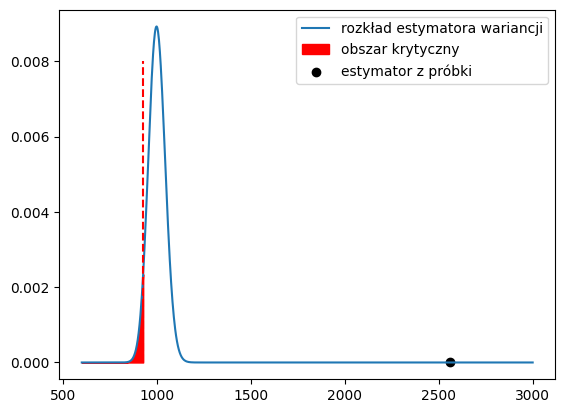

In [16]:
chi_left = scipy.stats.chi2.ppf(alfa,df=n)
p_value = scipy.stats.chi.cdf(chi_probka, df=n)
print(p_value, "p-value")

plt.plot(argumenty, scipy.stats.chi2.pdf(argumenty, df=n), label="rozkład estymatora wariancji")
plt.vlines( chi_left, ymin=0, ymax=0.008, linestyle="--", color="red")
plt.fill_between(x=argumenty,y1=scipy.stats.chi2.pdf(argumenty, df=n),where =(argumenty < chi_left), color='r', label="obszar krytyczny")
plt.scatter(chi_probka, 0, color="black", label="estymator z próbki")
plt.legend()
# Przyjmujemy hipotezę alternatywną 


### Prawdopodobieństwo popełnienia błędów I i II. rodzaju 

In [17]:

# 1 
trials = 1000
rejected = 0
for i in range(trials):
    sample = np.random.normal(loc=0.2, scale=np.sqrt(1.5), size=1000)
    chi_sample = np.sum((sample - srednia_populacji)**2)/h0_var
    if chi_left > chi_sample or chi_sample > chi_right:
        rejected += 1
print(f"błąd 1-szego rodzaju {rejected/trials}")

# 2 
# sprawdzimy błąd 2. rodzaju dla kilku wartości 
alternatives = [0.001, 0.9, 1.2, 1.3, 1.4]

for var in alternatives:
    accepted = 0
    for i in range(trials):
        sample = np.random.normal(loc=0.2, scale=np.sqrt(var), size=1000)
        chi_sample = np.sum((sample - srednia_populacji)**2)/h0_var
        if chi_left < chi_sample:
            accepted += 1
    print(f"bład 2. rodzaju dla wariancji {var} wynosi: {accepted/trials}, moc testu: {1-accepted/trials}")

błąd 1-szego rodzaju 0.093
bład 2. rodzaju dla wariancji 0.001 wynosi: 0.0, moc testu: 1.0
bład 2. rodzaju dla wariancji 0.9 wynosi: 0.0, moc testu: 1.0
bład 2. rodzaju dla wariancji 1.2 wynosi: 0.001, moc testu: 0.999
bład 2. rodzaju dla wariancji 1.3 wynosi: 0.058, moc testu: 0.942
bład 2. rodzaju dla wariancji 1.4 wynosi: 0.562, moc testu: 0.43799999999999994


### Interpretacja 
Przyjmujemy hipotezę zerową. 